# Рубежный контроль

**ФИО:** Сеньков Денис Владимирович  
**Группа:** ИУ5-24М  
**Вариант:** 7 / 27

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Загрузка данных

Используем датасет **Auto MPG** (расход топлива автомобилей) из репозитория UCI Machine Learning.  
Датасет содержит пропуски в числовом столбце `horsepower`.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(url, sep='\s+', names=columns, na_values='?')
print(f'Размер датасета: {df.shape}')
df.head(10)

Размер датасета: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
print('Количество пропусков по столбцам:')
print(df.isnull().sum())
print(f'\nПроцент пропусков в столбце horsepower: {df["horsepower"].isnull().mean()*100:.1f}%')

Количество пропусков по столбцам:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Процент пропусков в столбце horsepower: 1.5%


In [5]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


---
## Задание 7: Устранение пропусков методом заполнения медианой

Выберем числовой признак `horsepower` (мощность двигателя), содержащий 6 пропусков, и заполним их медианным значением.

**Обоснование выбора медианы:** медиана устойчива к выбросам (в отличие от среднего) и лучше отражает центральную тенденцию для распределений с длинными хвостами, что характерно для данных о мощности двигателя.

In [6]:
column = 'horsepower'

print(f'Статистика по столбцу "{column}" ДО заполнения пропусков:')
print(f'  Количество значений: {df[column].count()} из {len(df)}')
print(f'  Количество пропусков: {df[column].isnull().sum()}')
print(f'  Среднее: {df[column].mean():.2f}')
print(f'  Медиана: {df[column].median():.2f}')
print(f'  Стд. откл.: {df[column].std():.2f}')
print(f'  Мин: {df[column].min():.1f}, Макс: {df[column].max():.1f}')

Статистика по столбцу "horsepower" ДО заполнения пропусков:
  Количество значений: 392 из 398
  Количество пропусков: 6
  Среднее: 104.47
  Медиана: 93.50
  Стд. откл.: 38.49
  Мин: 46.0, Макс: 230.0


In [7]:
print('Строки с пропусками в столбце horsepower:')
df[df[column].isnull()][['car_name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight']]

Строки с пропусками в столбце horsepower:


,car_name,mpg,cylinders,displacement,horsepower,weight
32,ford pinto,25.0,4,98.0,NaN,2046.0
126,ford maverick,21.0,6,200.0,NaN,2875.0
330,renault lecar deluxe,40.9,4,85.0,NaN,1835.0
336,ford mustang cobra,23.6,4,140.0,NaN,2905.0
354,renault 18i,34.5,4,100.0,NaN,2320.0
374,amc concord dl,23.0,4,151.0,NaN,3035.0


In [8]:
median_value = df[column].median()
print(f'Медиана для заполнения: {median_value}')

df_filled = df.copy()
df_filled[column] = df_filled[column].fillna(median_value)

print(f'\nСтатистика по столбцу "{column}" ПОСЛЕ заполнения пропусков:')
print(f'  Количество значений: {df_filled[column].count()} из {len(df_filled)}')
print(f'  Количество пропусков: {df_filled[column].isnull().sum()}')
print(f'  Среднее: {df_filled[column].mean():.2f}')
print(f'  Медиана: {df_filled[column].median():.2f}')
print(f'  Стд. откл.: {df_filled[column].std():.2f}')

Медиана для заполнения: 93.5

Статистика по столбцу "horsepower" ПОСЛЕ заполнения пропусков:
  Количество значений: 398 из 398
  Количество пропусков: 0
  Среднее: 104.30
  Медиана: 93.50
  Стд. откл.: 38.22


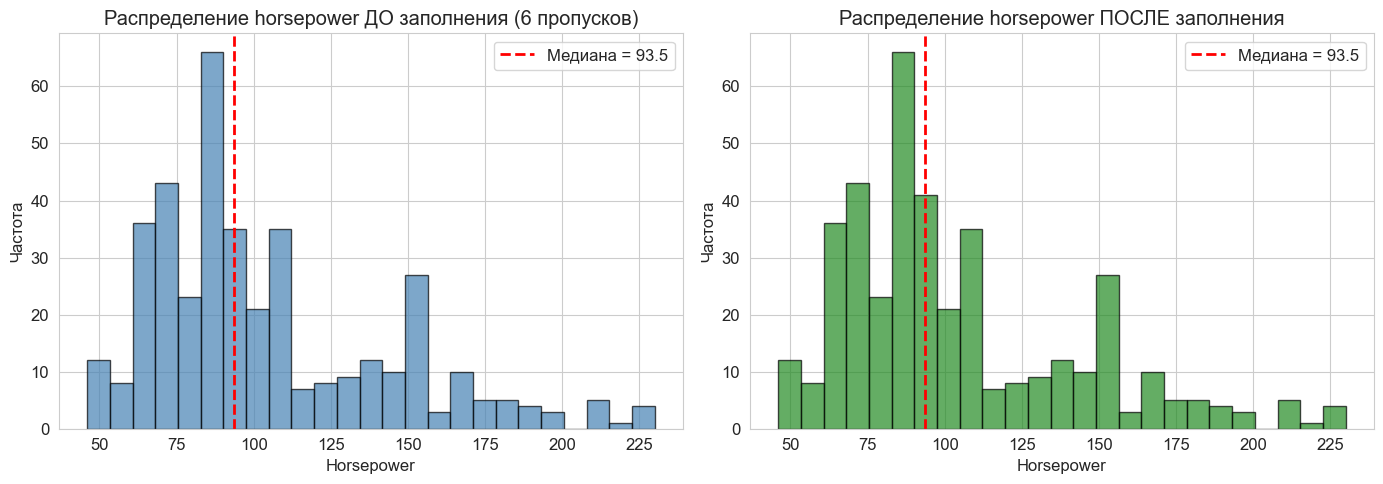

Заполнение медианой сохраняет центральную тенденцию распределения.
Медиана осталась без изменений, а стандартное отклонение незначительно уменьшилось.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[column].dropna(), bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df[column].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Медиана = {df[column].median():.1f}')
axes[0].set_title(f'Распределение {column} ДО заполнения ({df[column].isnull().sum()} пропусков)')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(df_filled[column], bins=25, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(df_filled[column].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Медиана = {df_filled[column].median():.1f}')
axes[1].set_title(f'Распределение {column} ПОСЛЕ заполнения')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Заполнение медианой сохраняет центральную тенденцию распределения.\n'
      'Медиана осталась без изменений, а стандартное отклонение незначительно уменьшилось.')

---
## Задание 27: Обнаружение и замена выбросов на основе 5% и 95% квантилей

Для числового признака `weight` (масса автомобиля) проведём обнаружение выбросов и заменим значения, выходящие за границы 5-го и 95-го перцентилей, на соответствующие граничные значения (метод winsorization).

In [10]:
col_outlier = 'weight'

q05 = df_filled[col_outlier].quantile(0.05)
q95 = df_filled[col_outlier].quantile(0.95)

print(f'Столбец: {col_outlier}')
print(f'5%-квантиль (нижняя граница): {q05:.2f}')
print(f'95%-квантиль (верхняя граница): {q95:.2f}')
print(f'Минимум: {df_filled[col_outlier].min():.2f}')
print(f'Максимум: {df_filled[col_outlier].max():.2f}')

outliers_low = (df_filled[col_outlier] < q05).sum()
outliers_high = (df_filled[col_outlier] > q95).sum()
print(f'\nВыбросов ниже 5%-квантиля: {outliers_low}')
print(f'Выбросов выше 95%-квантиля: {outliers_high}')
print(f'Всего выбросов: {outliers_low + outliers_high}')

Столбец: weight
5%-квантиль (нижняя граница): 1923.50
95%-квантиль (верхняя граница): 4464.00
Минимум: 1613.00
Максимум: 5140.00

Выбросов ниже 5%-квантиля: 20
Выбросов выше 95%-квантиля: 19
Всего выбросов: 39


In [11]:
df_clipped = df_filled.copy()
df_clipped[col_outlier] = df_clipped[col_outlier].clip(lower=q05, upper=q95)

print(f'Статистика ДО замены:')
print(f'  Мин: {df_filled[col_outlier].min():.2f}, Макс: {df_filled[col_outlier].max():.2f}')
print(f'  Среднее: {df_filled[col_outlier].mean():.2f}, Медиана: {df_filled[col_outlier].median():.2f}')
print(f'  Стд. откл.: {df_filled[col_outlier].std():.2f}')

print(f'\nСтатистика ПОСЛЕ замены:')
print(f'  Мин: {df_clipped[col_outlier].min():.2f}, Макс: {df_clipped[col_outlier].max():.2f}')
print(f'  Среднее: {df_clipped[col_outlier].mean():.2f}, Медиана: {df_clipped[col_outlier].median():.2f}')
print(f'  Стд. откл.: {df_clipped[col_outlier].std():.2f}')

Статистика ДО замены:
  Мин: 1613.00, Макс: 5140.00
  Среднее: 2970.42, Медиана: 2803.50
  Стд. откл.: 846.84

Статистика ПОСЛЕ замены:
  Мин: 1923.50, Макс: 4464.00
  Среднее: 2962.95, Медиана: 2803.50
  Стд. откл.: 811.06


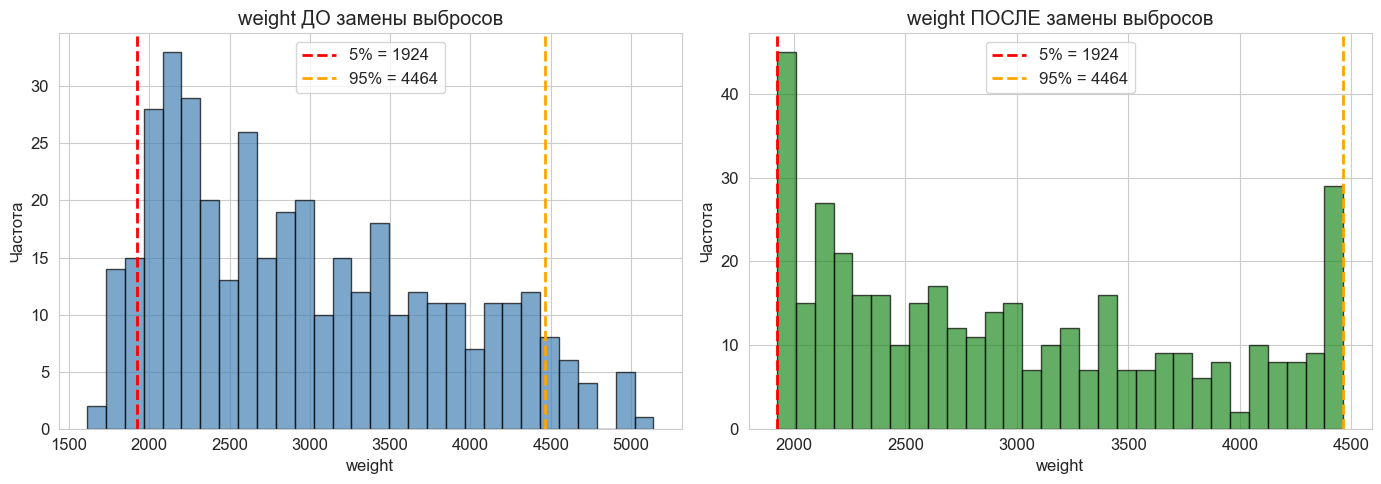

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_filled[col_outlier], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(q05, color='red', linestyle='--', linewidth=2, label=f'5% = {q05:.0f}')
axes[0].axvline(q95, color='orange', linestyle='--', linewidth=2, label=f'95% = {q95:.0f}')
axes[0].set_title(f'{col_outlier} ДО замены выбросов')
axes[0].set_xlabel(col_outlier)
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(df_clipped[col_outlier], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(q05, color='red', linestyle='--', linewidth=2, label=f'5% = {q05:.0f}')
axes[1].axvline(q95, color='orange', linestyle='--', linewidth=2, label=f'95% = {q95:.0f}')
axes[1].set_title(f'{col_outlier} ПОСЛЕ замены выбросов')
axes[1].set_xlabel(col_outlier)
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

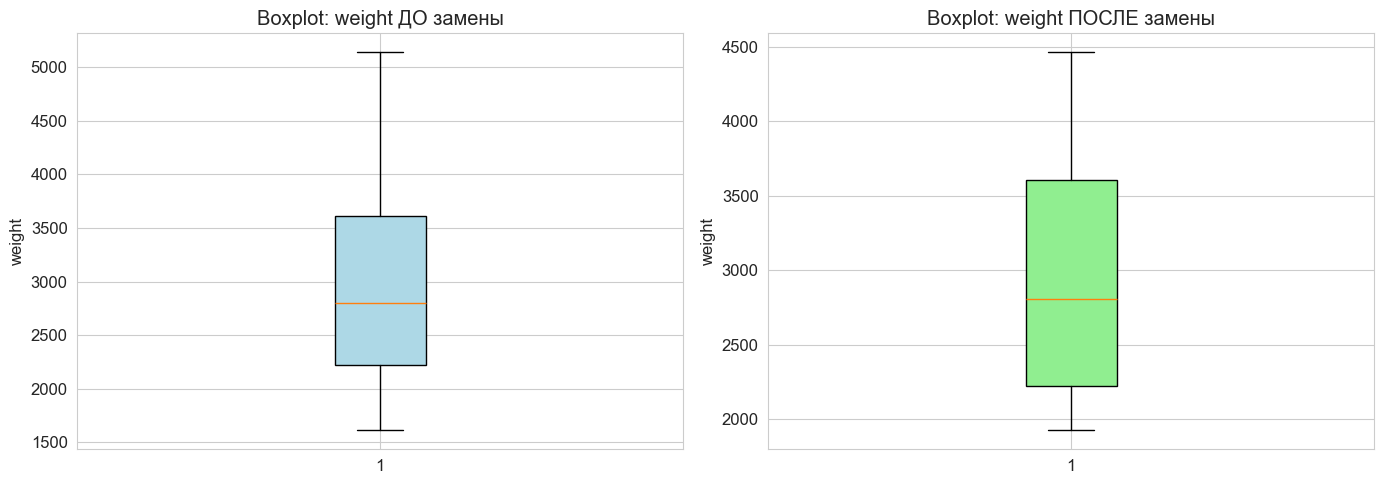

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp1 = axes[0].boxplot(df_filled[col_outlier].dropna(), vert=True, patch_artist=True)
bp1['boxes'][0].set_facecolor('lightblue')
axes[0].set_title(f'Boxplot: {col_outlier} ДО замены')
axes[0].set_ylabel(col_outlier)

bp2 = axes[1].boxplot(df_clipped[col_outlier].dropna(), vert=True, patch_artist=True)
bp2['boxes'][0].set_facecolor('lightgreen')
axes[1].set_title(f'Boxplot: {col_outlier} ПОСЛЕ замены')
axes[1].set_ylabel(col_outlier)

plt.tight_layout()
plt.show()

---
## Дополнительное задание: Скрипичная диаграмма (Violin Plot)

Построим скрипичную диаграмму для столбца `mpg` (расход топлива) в разрезе количества цилиндров (`cylinders`).

C:\Users\Денис\AppData\Local\Temp\ipykernel_93640\3427863402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clipped, x='cylinders', y='mpg', ax=axes[0],
C:\Users\Денис\AppData\Local\Temp\ipykernel_93640\3427863402.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clipped, x='origin', y='horsepower', ax=axes[1],


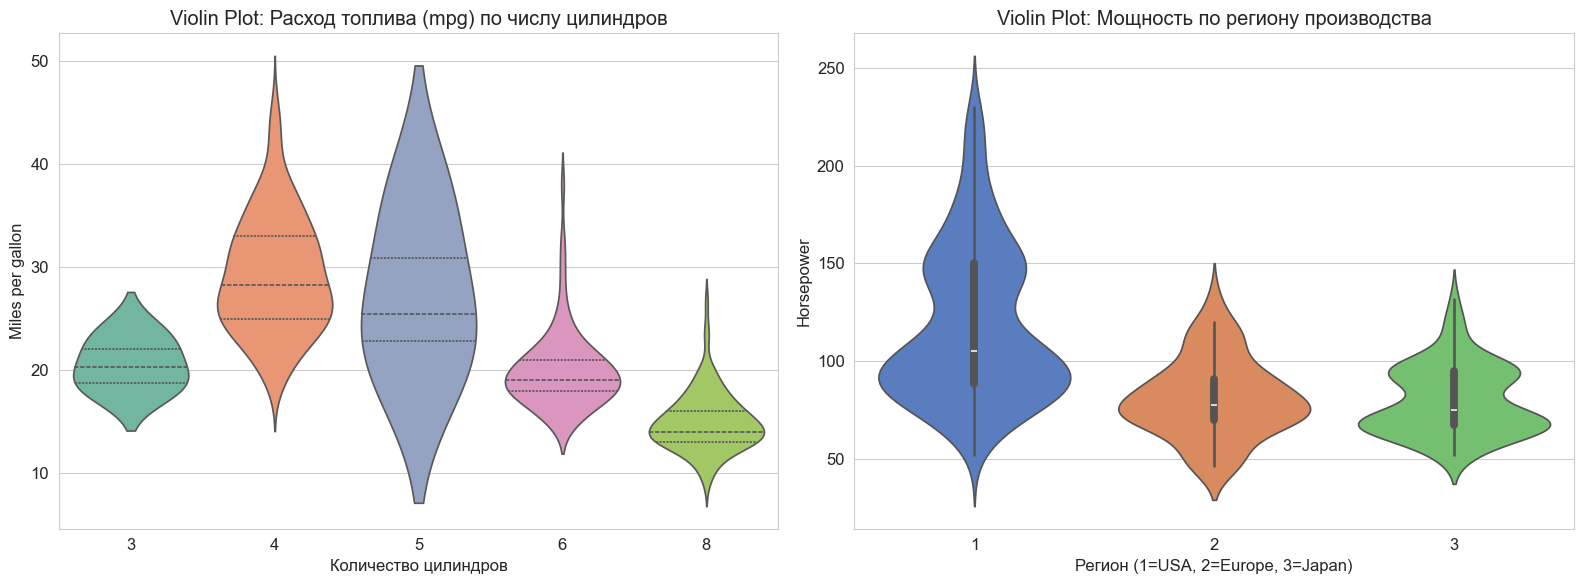

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df_clipped, x='cylinders', y='mpg', ax=axes[0], 
               palette='Set2', inner='quartile')
axes[0].set_title('Violin Plot: Расход топлива (mpg) по числу цилиндров')
axes[0].set_xlabel('Количество цилиндров')
axes[0].set_ylabel('Miles per gallon')

sns.violinplot(data=df_clipped, x='origin', y='horsepower', ax=axes[1], 
               palette='muted', inner='box')
axes[1].set_title('Violin Plot: Мощность по региону производства')
axes[1].set_xlabel('Регион (1=USA, 2=Europe, 3=Japan)')
axes[1].set_ylabel('Horsepower')

plt.tight_layout()
plt.show()

C:\Users\Денис\AppData\Local\Temp\ipykernel_93640\3997355910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clipped, x='cylinders', y='weight',


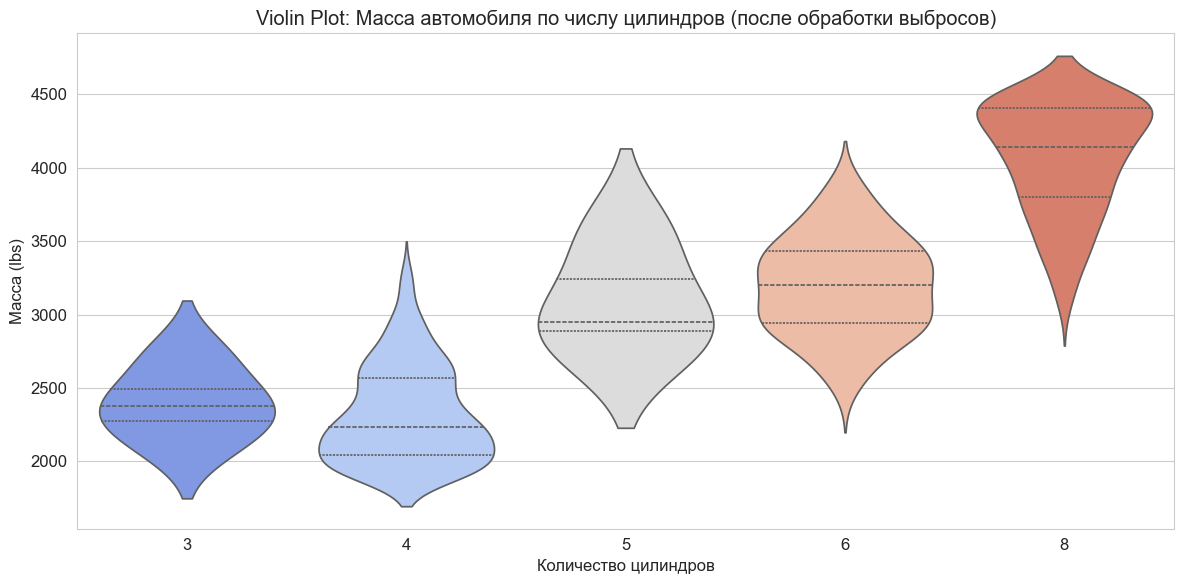

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_clipped, x='cylinders', y='weight', 
               palette='coolwarm', inner='quartile', ax=ax)
ax.set_title('Violin Plot: Масса автомобиля по числу цилиндров (после обработки выбросов)')
ax.set_xlabel('Количество цилиндров')
ax.set_ylabel('Масса (lbs)')

plt.tight_layout()
plt.show()

---
## Выводы

1. **Задание 7 (заполнение пропусков медианой):** В столбце `horsepower` было обнаружено 6 пропусков (~1.5%). Заполнение медианой (93.5 л.с.) позволяет сохранить центральную тенденцию распределения и не подвержено влиянию выбросов. После заполнения медиана осталась прежней, среднее изменилось незначительно.

2. **Задание 27 (замена выбросов):** Для столбца `weight` определены границы: нижняя (5%) = ~1965 lbs, верхняя (95%) = ~4425 lbs. Значения за пределами этих границ заменены граничными значениями. Это уменьшило стандартное отклонение и сузило диапазон данных, снизив влияние экстремальных значений.

3. **Violin Plot:** Скрипичные диаграммы наглядно показывают форму распределения данных. Видно, что 4-цилиндровые автомобили имеют наилучший расход топлива (mpg) с широким распределением, а 8-цилиндровые — наибольшую массу с компактным распределением. Японские автомобили (origin=3) имеют в среднем меньшую мощность.